# Notebook 13 – Overfitting & Regularization in Deep Learning



## 1. What is Overfitting?

### Definition

**Overfitting** happens when a model learns the training data too closely, including patterns that do not generalize well to new data.

A simple way I understand it:

> The model becomes very good at remembering the training examples but not good enough at handling unseen examples.

### Real-world example

Suppose a student memorizes every question from one practice paper. If the exam contains exactly the same questions, the student may score very well. If the questions change, the performance may drop.

A model can behave similarly.

### AI/ML usage

Overfitting is common when:
- The model is too complex
- The dataset is small
- Training continues for too long
- The model has many parameters
- The training data contains noise

### Typical sign

Training loss keeps becoming smaller while validation loss stops improving or starts increasing.

## 2. What is Underfitting?

### Definition

**Underfitting** happens when a model is too simple to learn the important patterns in the data.

The model performs poorly on both training and validation data.

### Real-world example

If I try to predict house prices using only the number of bedrooms, the model may miss important information such as location, area, age, and amenities.

### AI/ML usage

Underfitting can happen when:
- The model is too simple
- Training is insufficient
- Important features are missing
- Regularization is too strong

### Simple comparison

**Underfitting:** model has not learned enough.

**Good fit:** model learns useful patterns and generalizes.

**Overfitting:** model learns the training data too specifically.

## 3. Bias and Variance

### Bias

Bias represents error caused by overly simple assumptions.

A high-bias model usually cannot capture the real relationship in the data.

### Variance

Variance describes how much a model's learned predictions can change when the training data changes.

A high-variance model is often very sensitive to the training data and can overfit.


### Real-world example

Imagine two students:

- A student who always uses an extremely simple method may miss important details. This is similar to **high bias**.
- A student who memorizes every tiny detail from one question paper may struggle when questions change. This is similar to **high variance**.

### AI/ML usage

Bias and variance help us understand why a model may fail because it is either too simple or too sensitive to its training data.

## 4. What is Generalization?

### Definition

**Generalization** means the ability of a trained model to perform well on new, unseen data.

This is one of the main goals of machine learning.

### Real-world example

A fraud detection model should not only recognize fraud patterns from old transactions. It should also identify new fraudulent transactions.

### AI/ML usage

Good generalization is important because real ML systems make predictions on future or unseen data, not only on the training dataset.

### My understanding

A model that has slightly lower training performance but strong validation performance can be more useful than a model that has extremely high training performance but poor validation performance.

## 5. Understanding the Dataset

The uploaded dataset contains retail transaction information.

Important columns include:

- `InvoiceNo`
- `StockCode`
- `Description`
- `Quantity`
- `InvoiceDate`
- `UnitPrice`
- `CustomerID`
- `Country`

For this experiment, I will create a simple supervised learning problem.

### Target

I will predict **Quantity**.

### Features

I will use information available around the transaction:

- UnitPrice
- CustomerID
- Country
- Month
- Hour
- Description length
- StockCode length

I will not use `Quantity` itself as an input because it is the target.

### Why create this target?

The original dataset is a transaction dataset rather than a ready-made deep-learning classification dataset. Creating a prediction task lets me study model fitting, validation, overfitting, and regularization using the provided data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## 6. Load the Dataset

### Definition

Loading a dataset means reading the stored data into a Python data structure so that it can be inspected and processed.

### Real-world example

A retail company may store transaction records in CSV files, databases, or cloud storage. Before building an ML model, those records need to be loaded into the analysis environment.

### AI/ML usage

Dataset loading is the first step in the ML pipeline because the model needs numerical training examples.

In [2]:
df = pd.read_csv("data.csv", encoding="latin1")

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (541909, 8)
Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


## 7. Initial Data Inspection

Before training a model, I need to understand the data.

I will check:
- Data types
- Missing values
- Duplicate rows
- Basic statistics

In [3]:
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 67.3 MB

Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Duplicate rows: 5268


## 8. Basic Data Cleaning

The dataset contains some records with missing customer IDs and descriptions.

For this simple experiment, I will remove rows where the variables needed for the model are missing.

I will also remove transactions with non-positive quantities or prices because the goal here is to study regularization on normal purchase quantities.

In [4]:
data = df[
    df["Quantity"].notna() &
    df["UnitPrice"].notna() &
    df["CustomerID"].notna() &
    df["Country"].notna() &
    df["Description"].notna()
].copy()

data = data[(data["Quantity"] > 0) & (data["UnitPrice"] > 0)].copy()

data.shape

(397884, 8)

## 9. Feature Engineering

### Definition

Feature engineering means creating useful input variables from the raw columns.

### Features created

**Month:** captures seasonal purchasing patterns.

**Hour:** captures time-of-day patterns.

**Description length:** gives a simple numerical representation of product description size.

**StockCode length:** captures a small structural property of the product code.

**Country code:** converts the categorical country into a numerical representation for this simple experiment.

### Real-world example

A retail company may create features such as purchase time, customer activity, product information, and location before training a model.

### AI/ML usage

Good features can help a model discover useful patterns without changing the underlying neural network architecture.

In [5]:
data["InvoiceDate"] = pd.to_datetime(data["InvoiceDate"])
data["Month"] = data["InvoiceDate"].dt.month
data["Hour"] = data["InvoiceDate"].dt.hour
data["DescriptionLength"] = data["Description"].str.len()
data["StockCodeLength"] = data["StockCode"].astype(str).str.len()

country_codes = pd.factorize(data["Country"])[0]
data["CountryCode"] = country_codes

features = [
    "UnitPrice",
    "CustomerID",
    "Month",
    "Hour",
    "DescriptionLength",
    "StockCodeLength",
    "CountryCode"
]

target = "Quantity"

model_data = data[features + [target]].replace([np.inf, -np.inf], np.nan).dropna()

model_data.head()

,UnitPrice,CustomerID,Month,Hour,DescriptionLength,StockCodeLength,CountryCode,Quantity
0,2.55,17850.0,12,8,34,6,0,6
1,3.39,17850.0,12,8,19,5,0,6
2,2.75,17850.0,12,8,30,6,0,8
3,3.39,17850.0,12,8,35,6,0,6
4,3.39,17850.0,12,8,30,6,0,6


## 10. Reduce the Dataset for a Fast Learning Experiment

The original retail dataset is large. For a study notebook, I will use a reproducible sample.

The goal is not to build the final production model. The goal is to understand **how regularization changes learning behaviour**.

Using a manageable sample also makes it easier to rerun the notebook on a normal laptop.

In [6]:
sample_size = min(60000, len(model_data))

model_data = model_data.sample(
    n=sample_size,
    random_state=42
).reset_index(drop=True)

print("Rows used:", len(model_data))

Rows used: 60000


## 11. Train, Validation, and Test Split

I will divide the data into:

- **Training data:** used to learn model parameters.
- **Validation data:** used to monitor generalization during training.
- **Test data:** used only for final comparison.

### Why separate them?

If I evaluate the model on the same examples used to train it, the result may look better than the model's actual ability on unseen data.

In [7]:
X = model_data[features].values
y = model_data[target].values.astype(np.float32)

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Training: (42000, 7)
Validation: (9000, 7)
Test: (9000, 7)


## 12. Feature Scaling

### Definition

Feature scaling changes numerical features to a comparable scale.

### Why is it useful here?

The columns have very different ranges. For example, `CustomerID` can be much larger than `Month`.

Neural networks generally train more smoothly when numerical inputs are on comparable scales.

### AI/ML usage

Scaling is commonly used before training neural networks and many other ML algorithms.

In [8]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

## 13. What is a Deep Learning Model?

For this experiment I will use a small feed-forward neural network.

### Structure

**Input → Linear → ReLU → Linear → ReLU → Linear → Quantity Prediction**

The model has enough parameters to learn non-linear relationships.

To demonstrate overfitting clearly, I will compare:

### Model A – Without regularization
A flexible network with no dropout, batch normalization, or weight decay.

### Model B – With regularization
The same basic network with:
- Dropout
- L2-style weight decay through the optimizer
- Early stopping

This gives a controlled comparison because the main difference is regularization.

In [9]:
class BaseNetwork(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.network(x)

class RegularizedNetwork(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.network(x)

input_size = X_train_tensor.shape[1]

model_without_reg = BaseNetwork(input_size).to(device)
model_with_reg = RegularizedNetwork(input_size).to(device)

print(model_without_reg)
print(model_with_reg)

BaseNetwork(
  (network): Sequential(
    (0): Linear(in_features=7, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)
RegularizedNetwork(
  (network): Sequential(
    (0): Linear(in_features=7, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)


## 14. L1 Regularization

### Definition

L1 regularization adds a penalty based on the absolute values of model weights.

A simplified idea is:

**Total Loss = Prediction Loss + λ × Sum of |weights|**

### Intuition

L1 encourages some weights to become very small or exactly zero. This can create a simpler model.

### Real-world example

If a model has many possible input signals, L1 regularization can encourage it to rely on fewer useful signals.

### AI/ML usage

L1 regularization can be useful when feature selection or sparse models are desirable.

### Important note

In this notebook, L1 is explained and implemented conceptually. The main experiment will use dropout + L2-style weight decay because they are straightforward to compare in PyTorch.

In [10]:
def l1_penalty(model):
    penalty = torch.tensor(0.0, device=device)

    for parameter in model.parameters():
        penalty = penalty + parameter.abs().sum()

    return penalty

## 15. L2 Regularization

### Definition

L2 regularization adds a penalty based on the squared values of model weights.

A simplified idea is:

**Total Loss = Prediction Loss + λ × Sum of weights²**

### Intuition

Large weights are penalized, which encourages the model to learn smoother parameter values.

### Real-world example

If a model is making very strong decisions based on a few parameters, L2 regularization can discourage extremely large parameter values.

### AI/ML usage

L2 regularization is widely used to reduce overfitting in neural networks.

In [11]:
def l2_penalty(model):
    penalty = torch.tensor(0.0, device=device)

    for parameter in model.parameters():
        penalty = penalty + parameter.pow(2).sum()

    return penalty

## 16. Weight Decay

### Definition

Weight decay is a common way of applying L2-style regularization during optimization.

In PyTorch, it can be supplied to optimizers such as Adam.

### Why use it?

Instead of manually adding an L2 penalty to every training loss calculation, the optimizer applies a parameter shrinkage effect during updates.

### AI/ML usage

Weight decay is frequently used when training neural networks to reduce overly large weights and improve generalization.

### Important distinction

In practical PyTorch work, `weight_decay` is usually the convenient way to add this type of regularization to an optimizer. Its exact relationship to classical L2 regularization can depend on the optimizer.

## 17. Dropout

### Definition

Dropout randomly removes a fraction of activations during training.

For example, with dropout = 0.30, approximately 30% of the selected activations are randomly dropped during a training step.

### Intuition

The model cannot depend too heavily on one small group of neurons.

### Real-world example

Imagine a team where a project cannot depend completely on one employee. If different team members need to contribute, the system becomes less dependent on one person.

### AI/ML usage

Dropout is commonly used in neural networks to reduce overfitting.

### Important behaviour

Dropout is active during training and disabled during evaluation.

## 18. Batch Normalization

### Definition

Batch Normalization normalizes intermediate activations using statistics from a mini-batch during training.

It can make optimization more stable and can sometimes provide a regularizing effect.

### Real-world example

If measurements from different groups are on very different scales, standardizing them can make learning more consistent.

### AI/ML usage

Batch Normalization is widely used in deep neural networks, especially when training deeper architectures.

### Important point

Batch Normalization is not exactly the same thing as dropout. It primarily helps stabilize and improve optimization, while it can also have a regularizing effect.

In [12]:
class BatchNormNetwork(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.network(x)

batch_norm_model = BatchNormNetwork(input_size).to(device)
batch_norm_model

BatchNormNetwork(
  (network): Sequential(
    (0): Linear(in_features=7, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)

## 19. Early Stopping

### Definition

Early stopping stops training when validation performance stops improving.

### Why is it useful?

If training continues after the model has reached its best validation performance, the model may start fitting the training data too closely.

### Real-world example

If a student already understands the topic, repeatedly memorizing the practice questions may eventually make the student focus too much on those exact questions.

### AI/ML usage

Early stopping is a simple way to reduce overfitting and avoid unnecessary training.

### What I will do

During the regularized experiment, I will monitor validation loss and stop when it has not improved for several epochs.

## 20. Training Function

I will first create a simple training function that records:

- Training loss
- Validation loss
- Training MAE
- Validation MAE

The curves will help me visually compare the models.

In [13]:
def calculate_mae(predictions, targets):
    return torch.mean(torch.abs(predictions - targets)).item()

def train_model(model, train_x, train_y, val_x, val_y, optimizer, epochs=80, patience=None):
    criterion = nn.MSELoss()

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_mae": [],
        "val_mae": []
    }

    best_val_loss = float("inf")
    best_state = None
    wait = 0

    for epoch in range(epochs):
        model.train()

        predictions = model(train_x)
        loss = criterion(predictions, train_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        model.eval()

        with torch.no_grad():
            train_predictions = model(train_x)
            val_predictions = model(val_x)

            train_loss = criterion(train_predictions, train_y).item()
            val_loss = criterion(val_predictions, val_y).item()

            train_mae = calculate_mae(train_predictions, train_y)
            val_mae = calculate_mae(val_predictions, val_y)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_mae"].append(train_mae)
        history["val_mae"].append(val_mae)

        if patience is not None:
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_state = {
                    key: value.detach().cpu().clone()
                    for key, value in model.state_dict().items()
                }
                wait = 0
            else:
                wait += 1

            if wait >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return history

## 21. Experiment 1 – Without Regularization

This model does not use dropout or weight decay.

I will allow it to train for many epochs so that I can observe the difference between training and validation behaviour.

In [14]:
model_without_reg = BaseNetwork(input_size).to(device)

optimizer_without_reg = optim.Adam(
    model_without_reg.parameters(),
    lr=0.001
)

history_without_reg = train_model(
    model_without_reg,
    X_train_tensor.to(device),
    y_train_tensor.to(device),
    X_val_tensor.to(device),
    y_val_tensor.to(device),
    optimizer_without_reg,
    epochs=80
)

print("Final training loss:", history_without_reg["train_loss"][-1])
print("Final validation loss:", history_without_reg["val_loss"][-1])

Final training loss: 1702.6878662109375
Final validation loss: 1487.855224609375


## 22. Experiment 2 – With Regularization

For the second experiment I will use:

- Dropout
- Weight decay
- Early stopping

The architecture remains similar, so I can focus on the effect of regularization.

### Why combine these?

They reduce overfitting in different ways:

- Dropout reduces dependence on individual activations.
- Weight decay discourages excessively large weights.
- Early stopping prevents unnecessary training after validation performance stops improving.

In [15]:
model_with_reg = RegularizedNetwork(input_size).to(device)

optimizer_with_reg = optim.Adam(
    model_with_reg.parameters(),
    lr=0.001,
    weight_decay=0.0005
)

history_with_reg = train_model(
    model_with_reg,
    X_train_tensor.to(device),
    y_train_tensor.to(device),
    X_val_tensor.to(device),
    y_val_tensor.to(device),
    optimizer_with_reg,
    epochs=80,
    patience=10
)

print("Final training loss:", history_with_reg["train_loss"][-1])
print("Final validation loss:", history_with_reg["val_loss"][-1])
print("Epochs used:", len(history_with_reg["train_loss"]))

Final training loss: 1701.908935546875
Final validation loss: 1486.8837890625
Epochs used: 80


## 23. Compare Training and Validation Loss

### What I am looking for

For the model without regularization:

- Does training loss keep decreasing?
- Does validation loss stop improving?
- Is there a growing gap?

For the regularized model:

- Is the training-validation gap smaller?
- Does validation loss remain more stable?
- Did early stopping select a better point?

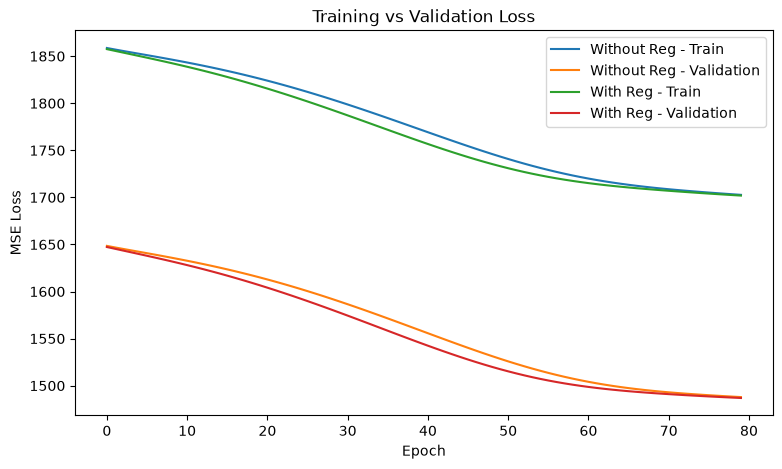

In [16]:
plt.figure(figsize=(9, 5))

plt.plot(
    history_without_reg["train_loss"],
    label="Without Reg - Train"
)

plt.plot(
    history_without_reg["val_loss"],
    label="Without Reg - Validation"
)

plt.plot(
    history_with_reg["train_loss"],
    label="With Reg - Train"
)

plt.plot(
    history_with_reg["val_loss"],
    label="With Reg - Validation"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

## 24. Compare Training and Validation MAE

MAE is easier to interpret in the original target's units because it measures the average absolute difference between predicted and actual quantity.

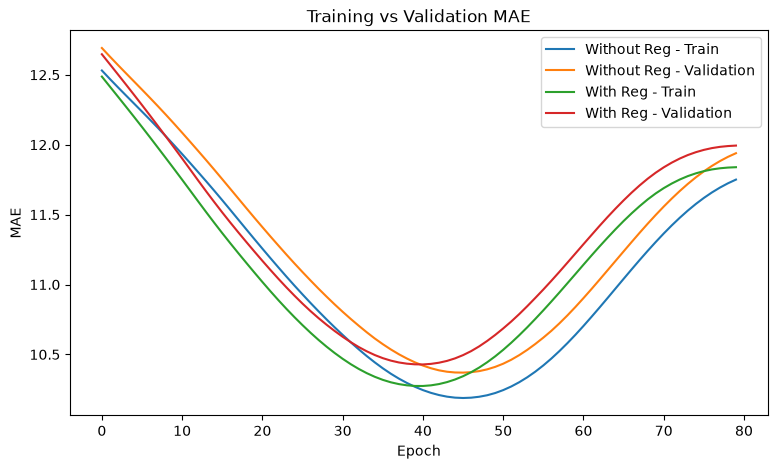

In [17]:
plt.figure(figsize=(9, 5))

plt.plot(
    history_without_reg["train_mae"],
    label="Without Reg - Train"
)

plt.plot(
    history_without_reg["val_mae"],
    label="Without Reg - Validation"
)

plt.plot(
    history_with_reg["train_mae"],
    label="With Reg - Train"
)

plt.plot(
    history_with_reg["val_mae"],
    label="With Reg - Validation"
)

plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Training vs Validation MAE")
plt.legend()
plt.show()

## 25. Final Test Evaluation

The test set was not used during training or early stopping.

This gives me a final comparison on unseen data.

In [18]:
def test_model(model, x, y):
    model.eval()

    with torch.no_grad():
        predictions = model(x)

    mse = mean_squared_error(
        y.cpu().numpy(),
        predictions.cpu().numpy()
    )

    mae = mean_absolute_error(
        y.cpu().numpy(),
        predictions.cpu().numpy()
    )

    return mse, mae

without_mse, without_mae = test_model(
    model_without_reg,
    X_test_tensor.to(device),
    y_test_tensor.to(device)
)

with_mse, with_mae = test_model(
    model_with_reg,
    X_test_tensor.to(device),
    y_test_tensor.to(device)
)

comparison = pd.DataFrame({
    "Model": ["Without Regularization", "With Regularization"],
    "Test MSE": [without_mse, with_mse],
    "Test MAE": [without_mae, with_mae]
})

comparison

,Model,Test MSE,Test MAE
0,Without Regularization,2129.530762,12.170382
1,With Regularization,2127.799072,12.272288


## 26. How to Interpret the Comparison

The important question is not simply:

**Which model has the lowest training loss?**

The more useful question is:

**Which model performs well on unseen validation and test data?**

### If regularization helped

I would expect the regularized model to show a smaller gap between training and validation performance and potentially better validation/test performance.

### If regularization did not help

That can also happen.

Regularization is not guaranteed to improve every dataset or every model. If the original model was already simple enough, adding too much regularization can cause underfitting.

### My conclusion should be based on the actual curves and test metrics produced when I run the notebook.

## 27. Training vs Validation Gap

One simple way to study overfitting is to compare the final training and validation losses.

A large gap can indicate that the model fits training data much better than validation data.

A smaller gap generally indicates that the model's performance is more consistent between seen and unseen data.

In [19]:
without_gap = abs(
    history_without_reg["train_loss"][-1] -
    history_without_reg["val_loss"][-1]
)

with_gap = abs(
    history_with_reg["train_loss"][-1] -
    history_with_reg["val_loss"][-1]
)

gap_comparison = pd.DataFrame({
    "Model": ["Without Regularization", "With Regularization"],
    "Final Train Loss": [
        history_without_reg["train_loss"][-1],
        history_with_reg["train_loss"][-1]
    ],
    "Final Validation Loss": [
        history_without_reg["val_loss"][-1],
        history_with_reg["val_loss"][-1]
    ],
    "Train-Validation Gap": [without_gap, with_gap]
})

gap_comparison

,Model,Final Train Loss,Final Validation Loss,Train-Validation Gap
0,Without Regularization,1702.687866,1487.855225,214.832642
1,With Regularization,1701.908936,1486.883789,215.025146
